# Lab 1: Linear regression

## Decision and Machine Learning, Centrale Lille

In this lab, we implement linear regression and ridge regression on a medical data example. The data come from a medical study (Stamey et al., 1989), whose goal was to predict the level of prostate-specific antigen (`lpsa`) from clinical measurements. These clinical exams are carried out before a possible prostatectomy.

The measurements are log cancer volume `lcavol`, log prostate weight `lweight`, age of the patient `age`, log of benign prostatic hyperplasia amount `lbph`, seminal vesicle invasion `svi`, log of capsular penetration `lcp`, Gleason score `gleason`, and percent of Gleason scores 4 or 5 `pgg45`. The variable `svi` is binary, `gleason` is ordinal, the others are quantitative.

**Report by Ugo Roccamatisi.**


In [1]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

### Part 1 - Linear regression

In this first part, we focus on using linear regression.

**Q1.** Load the data from the `.npy` files in this folder (use `np.load`). How many examples are there? How many features?

In [2]:
from pathlib import Path
# Paths relative to the notebook, so the folder can be moved.
X = np.load(Path('data_X.npy'))
y = np.load(Path('data_y.npy'))
feature_names = ['lcavol','lweight','age','lbph','svi','lcp','gleason','pgg45']
print(f'Examples: {X.shape[0]}, features: {X.shape[1]}, target: {y.shape}')

Examples: 97, features: 8, target: (97,)


**Answer.** The printed shapes give 97 observations and 8 explanatory variables.

**Q2.** Check whether there are some missing entries in the dataset (both in X and y). Use `np.isnan`.

In [3]:
# np.isnan returns a mask; its sum counts the missing values.
print('Missing values in X:', np.isnan(X).sum())
print('Missing values in y:', np.isnan(y).sum())

Missing values in X: 0
Missing values in y: 0


**Answer.** The count shows that there are no missing values in either the predictors or the target.

**Q3.** Divide the dataset into a training set (80%) and a test set (20%), using `train_test_split` with `random_state = 0` (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)).

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=0)
print('Train/test:', X_train.shape, X_test.shape)

Train/test: (77, 8) (20, 8)


**Q4.** Standardize the training set, and apply the same operation to the test set. Use `StandardScaler` (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)). Recall what standardization means.

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)  # Means and standard deviations computed on the training set only.
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print('Train means:',np.round(X_train_s.mean(axis=0),4))
print('Train standard deviations:',np.round(X_train_s.std(axis=0),4))

Train means: [ 0. -0. -0. -0.  0.  0.  0.  0.]
Train standard deviations: [1. 1. 1. 1. 1. 1. 1. 1.]


**Answer.** Standardizing means subtracting the training mean of each column, then dividing by its standard deviation; the same parameters are applied to the test set.

**Q5.** Compute the auto-covariance matrix from the training set, and display it (you might want to use `plt.imshow`). What can we learn from this ?

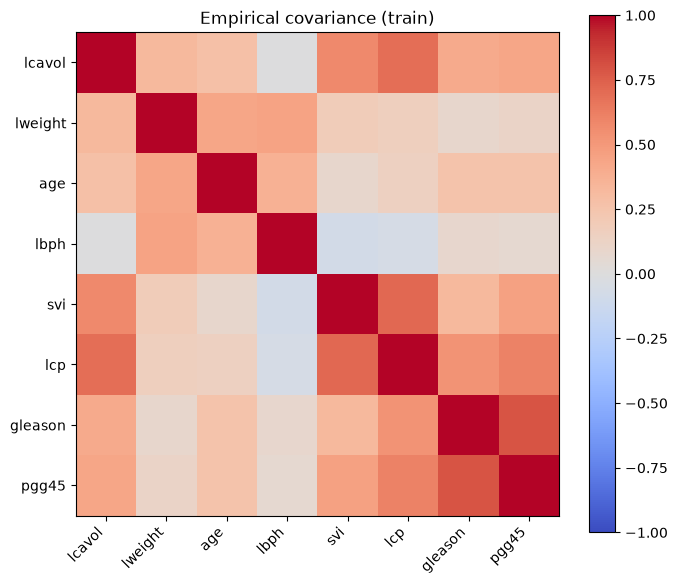

Strongest off-diagonal correlations:
gleason pgg45 0.789
svi lcp 0.712
lcavol lcp 0.692
lcp pgg45 0.605


In [6]:
# Unbiased empirical covariance of the standardized features.
cov = np.cov(X_train_s,rowvar=False)
fig, ax = plt.subplots(figsize=(7,6))
im=ax.imshow(cov,cmap='coolwarm',vmin=-1,vmax=1)
ax.set(xticks=range(8),yticks=range(8),xticklabels=feature_names,yticklabels=feature_names,title='Empirical covariance (train)')
plt.setp(ax.get_xticklabels(),rotation=45,ha='right');fig.colorbar(im,ax=ax);fig.tight_layout();plt.show()
print('Strongest off-diagonal correlations:')
for i,j in sorted(((i,j) for i in range(8) for j in range(i+1,8)),key=lambda ij:abs(cov[ij]),reverse=True)[:4]:print(feature_names[i],feature_names[j],round(cov[i,j],3))

**Answer.** The diagonal is about 1 after standardization; the off-diagonal terms reveal linear dependencies and possible collinearity. The printed list gives the most correlated pairs.

**Q6.** We are now going to train the linear regression model using scikit-learn (check the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)). Use the `.fit` method on the training set. Retrieve the coefficients obtained by scikit-learn using the attributes `.intercept_` and `.coef_`, and check that it corresponds to the closed-form solution from the lecture (you might want to use `np.hstack` to concatenate X with a column of ones).

In [7]:
from sklearn.linear_model import LinearRegression
ols=LinearRegression().fit(X_train_s,y_train)
# The column of ones encodes the intercept; lstsq is numerically robust.
A=np.column_stack((np.ones(len(X_train_s)),X_train_s))
beta=np.linalg.lstsq(A,y_train,rcond=None)[0]
print('sklearn intercept and coefficients:',np.round(np.r_[ols.intercept_,ols.coef_],4))
print('Least-squares solution:',np.round(beta,4))
print('Numerically equal:',np.allclose(beta,np.r_[ols.intercept_,ols.coef_]))

sklearn intercept and coefficients: [ 2.5334  0.7649  0.2151 -0.1982  0.1701  0.3377 -0.2353  0.106   0.0612]
Least-squares solution: [ 2.5334  0.7649  0.2151 -0.1982  0.1701  0.3377 -0.2353  0.106   0.0612]
Numerically equal: True


**Answer.** The coefficients and intercept match the least-squares solution on the augmented matrix to numerical precision.

**Q7.** Obtain the model predictions on the test set using the `.predict` method. Then compute the MSE and the MAE (you may want to use the functions below).

In [8]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
pred_ols=ols.predict(X_test_s)
mse_ols=mean_squared_error(y_test,pred_ols);mae_ols=mean_absolute_error(y_test,pred_ols)
print(f'Linear regression: MSE {mse_ols:.4f}; MAE {mae_ols:.4f}')

Linear regression: MSE 0.5402; MAE 0.5645


### Part 2 - Ridge regression

In this second part, we now turn to ridge regression.

**Q1.** Fit the ridge regression model (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)) with $\lambda = 1$, using the `.fit` method on the training set. Again, retrieve the coefficients, and check that they match with the closed-form solution from the lecture. How do they differ from the ones obtained with linear regression ?

In [9]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1).fit(X_train_s,y_train)
# sklearn does not penalize the intercept: center y and X before solving.
xc=X_train_s-X_train_s.mean(axis=0);yc=y_train-y_train.mean()
w=np.linalg.solve(xc.T@xc+np.eye(X.shape[1]),xc.T@yc)
b=ridge.intercept_  # mean(y) - mean(X) @ w
print('Ridge coefficients:',np.round(ridge.coef_,4))
print('Closed-form solution:',np.round(w,4))
print('Numerically equal:',np.allclose(w,ridge.coef_))
print('OLS/ridge L2 norms:',round(np.linalg.norm(ols.coef_),4),round(np.linalg.norm(w),4))

Ridge coefficients: [ 0.7422  0.216  -0.1897  0.1655  0.3289 -0.2098  0.1028  0.0594]
Closed-form solution: [ 0.7422  0.216  -0.1897  0.1655  0.3289 -0.2098  0.1028  0.0594]
Numerically equal: True
OLS/ridge L2 norms: 0.9401 0.9095


**Answer.** The L2 penalty shrinks the coefficients overall. The closed-form solution does not penalize the intercept, consistent with `Ridge`.

**Q2.** Obtain the model predictions on the test set using the `.predict` method, then compute the MSE and the MAE. Do we get better or worse predictions than before ? Comment.

In [10]:
pred_ridge=ridge.predict(X_test_s)
mse_ridge=mean_squared_error(y_test,pred_ridge);mae_ridge=mean_absolute_error(y_test,pred_ridge)
print(f'Ridge alpha=1: MSE {mse_ridge:.4f}; MAE {mae_ridge:.4f}')
print(f'Ridge - OLS differences: MSE {mse_ridge-mse_ols:+.4f}, MAE {mae_ridge-mae_ols:+.4f}')

Ridge alpha=1: MSE 0.5234; MAE 0.5564
Ridge - OLS differences: MSE -0.0168, MAE -0.0081


**Answer.** Both MSE and MAE decrease slightly, so this amount of regularization improves prediction on this test split; a single split does not guarantee a general improvement.

**Q3.** We are now going to assess the impact of the regularization coefficient $\lambda$.

To do so, vary $\lambda$ from $10^{-3}$ and $10^3$ (use `np.logspace`), and for each value of $\lambda$, retrain the ridge regression model and keep the values of the coefficients (ignoring the intercept).

Display the evolution of the coefficients w.r.t. $\lambda$ (use a logarithmic scale for the x-axis). Comment.

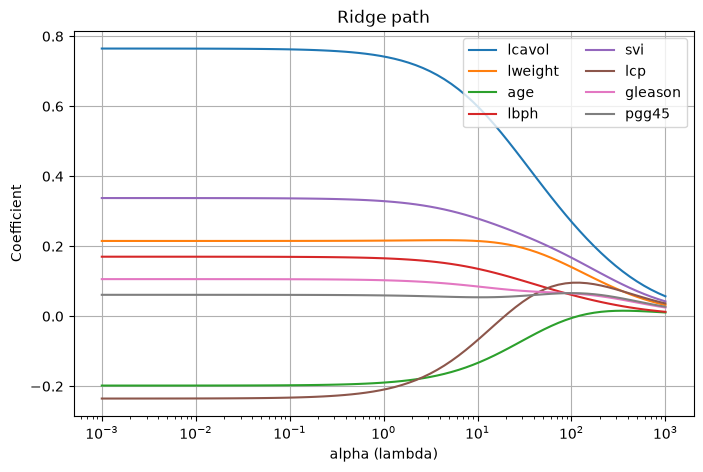

In [11]:
alphas=np.logspace(-3,3,80)
path=np.array([Ridge(alpha=a).fit(X_train_s,y_train).coef_ for a in alphas])
fig,ax=plt.subplots(figsize=(8,5))
for j,name in enumerate(feature_names): ax.plot(alphas,path[:,j],label=name)
ax.set_xscale('log');ax.set(xlabel='alpha (lambda)',ylabel='Coefficient',title='Ridge path');ax.legend(ncol=2);ax.grid(True);plt.show()

**Answer.** As alpha increases, the coefficients gradually shrink towards zero, generally without becoming exactly zero.

**Q4.** Now remains the question of choosing the optimal $\lambda$. We are going to select it with a 5-fold cross-validation.

Display the evolution of the cross-validated MSE w.r.t. $\lambda$ (use again a logarithmic scale for the x-axis), and display the best $\lambda$ with a `plt.axvline`.

Now retrain the ridge regression model with the selected $\lambda$, and assess its performance in terms of MSE and MAE. Comment.

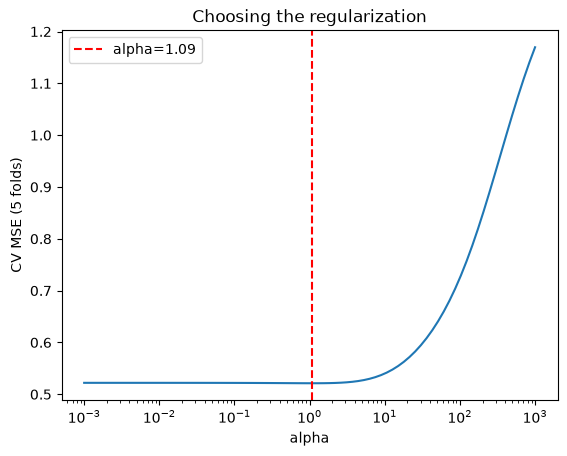

selected alpha 1.091; CV MSE 0.5213; test MSE 0.5219; test MAE 0.5558


In [12]:
from sklearn.model_selection import KFold
# In each fold, the scaler is fitted on the training subset only.
kf=KFold(n_splits=5,shuffle=True,random_state=0)
fold_mse=[]
for alpha in alphas:
    scores=[]
    for it,iv in kf.split(X_train):
        sc=StandardScaler().fit(X_train[it])
        model=Ridge(alpha=alpha).fit(sc.transform(X_train[it]),y_train[it])
        scores.append(mean_squared_error(y_train[iv],model.predict(sc.transform(X_train[iv]))))
    fold_mse.append(np.mean(scores))
fold_mse=np.array(fold_mse);best_alpha=alphas[np.argmin(fold_mse)]
fig,ax=plt.subplots();ax.plot(alphas,fold_mse);ax.axvline(best_alpha,color='r',ls='--',label=f'alpha={best_alpha:.3g}')
ax.set_xscale('log');ax.set(xlabel='alpha',ylabel='CV MSE (5 folds)',title='Choosing the regularization');ax.legend();plt.show()
best_ridge=Ridge(alpha=best_alpha).fit(X_train_s,y_train)
p=best_ridge.predict(X_test_s)
print(f'selected alpha {best_alpha:.4g}; CV MSE {fold_mse.min():.4f}; test MSE {mean_squared_error(y_test,p):.4f}; test MAE {mean_absolute_error(y_test,p):.4f}')

### Part 3 (Bonus) - LASSO

Display the same kind of plots as in Part 2, but using LASSO regression instead of ridge regression (see [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html). In particular, comment on the following points :
* Do the regression coefficients evolve in the same way as ridge regression ? What kind of solutions do we obtain ?
* Do we get the same optimal lambda ?

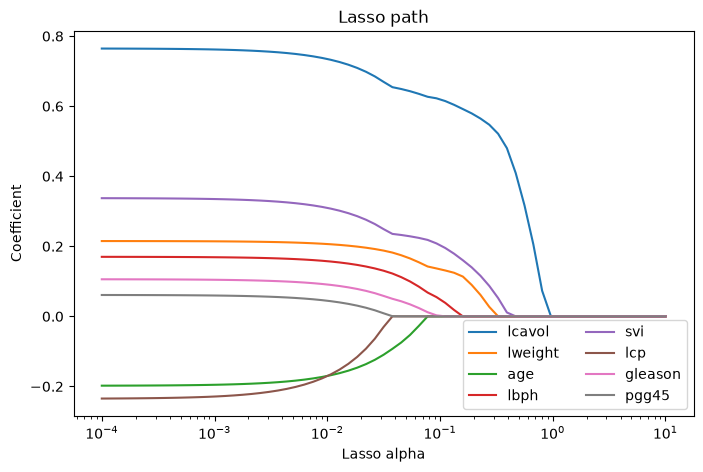

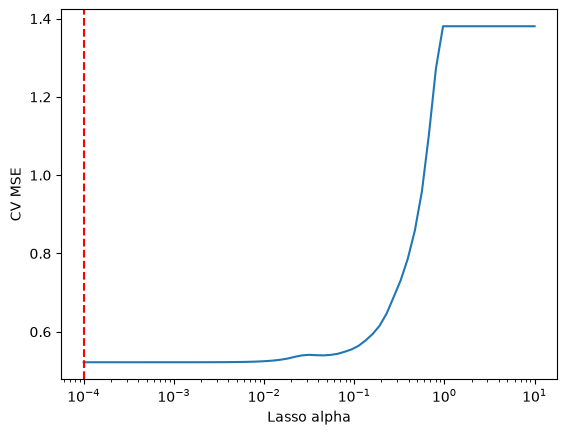

Lasso alpha 0.0001, zero coefficients 0/8, test MSE 0.5399


In [13]:
from sklearn.linear_model import Lasso
# Bonus: the Lasso convention is (1/(2n))||y-Xw||² + alpha||w||₁.
lasso_alphas=np.logspace(-4,1,65)
lasso_path=np.array([Lasso(alpha=a,max_iter=20000).fit(X_train_s,y_train).coef_ for a in lasso_alphas])
fig,ax=plt.subplots(figsize=(8,5))
for j,name in enumerate(feature_names):ax.plot(lasso_alphas,lasso_path[:,j],label=name)
ax.set_xscale('log');ax.set(xlabel='Lasso alpha',ylabel='Coefficient',title='Lasso path');ax.legend(ncol=2);plt.show()
cv_lasso=[]
for a in lasso_alphas:
    fold=[]
    for it,iv in kf.split(X_train):
        sc=StandardScaler().fit(X_train[it]);m=Lasso(alpha=a,max_iter=20000).fit(sc.transform(X_train[it]),y_train[it])
        fold.append(mean_squared_error(y_train[iv],m.predict(sc.transform(X_train[iv]))))
    cv_lasso.append(np.mean(fold))
a_lasso=lasso_alphas[np.argmin(cv_lasso)]
fig,ax=plt.subplots();ax.plot(lasso_alphas,cv_lasso);ax.axvline(a_lasso,color='r',ls='--');ax.set_xscale('log');ax.set(xlabel='Lasso alpha',ylabel='CV MSE');plt.show()
m=Lasso(alpha=a_lasso,max_iter=20000).fit(X_train_s,y_train)
print(f'Lasso alpha {a_lasso:.4g}, zero coefficients {np.sum(m.coef_==0)}/8, test MSE {mean_squared_error(y_test,m.predict(X_test_s)):.4f}')

**Answer.** Unlike ridge, the Lasso can set coefficients exactly to zero: it performs variable selection. Its alpha values follow a different penalty convention, so the optimal alphas are not directly comparable.